# Setup & EDA

In [2]:
import os
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split

In [3]:
torch.set_printoptions(precision=2, sci_mode=False)
pd.options.display.float_format = '{:.2f}'.format

In [4]:
cpu_count = os.cpu_count()

if cpu_count is not None:
  print(f"Number of CPU cores: {cpu_count}")
else:
  print("Could not determine CPU count")

Number of CPU cores: 12


In [5]:
if torch.cuda.is_available():
  print("CUDA is available. PyTorch can use the GPU.")
  print("GPU Name:", torch.cuda.get_device_name(0))
  print("Number of GPUs:", torch.cuda.device_count())
else:
  print("CUDA is not available. PyTorch will use the CPU.")

CUDA is not available. PyTorch will use the CPU.


Auto-detect environment

In [6]:
KAGGLE_DIR = Path("/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1")

if KAGGLE_DIR.exists():
  DATA_DIR = KAGGLE_DIR
  IS_KAGGLE = True
  print("Environment: Kaggle")
else:
  DATA_DIR = Path("data")
  IS_KAGGLE = False
  print("Environment: Local")

IMAGE_DIR = DATA_DIR / "images"
TRAIN_CSV = DATA_DIR / "train.csv"
TEST_CSV = DATA_DIR / "test.csv"
SAMPLE_CSV = DATA_DIR / "sample_submission.csv"

Environment: Local


Runtime constants (auto-configured by environment)

In [7]:
DEBUG = not IS_KAGGLE
DEBUG_BATCHES = 5
DEBUG_EPOCHS = 2
NUM_EPOCHS = DEBUG_EPOCHS if DEBUG else 20
PATIENCE = 5
NUM_WORKERS = 0 if not IS_KAGGLE else 2

print(f"Debug mode   : {DEBUG}")
print(f"Num epochs   : {NUM_EPOCHS}")
print(f"Num workers  : {NUM_WORKERS}")

Debug mode   : True
Num epochs   : 2
Num workers  : 0


Count PNG Files in Images Folder

In [8]:
all_images = list(IMAGE_DIR.glob("*.png"))
print(f"Total PNG files in images folder: {len(all_images)}")

Total PNG files in images folder: 88337


Load & Inspect CSVs

In [9]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train CSV shape:", train_df.shape)
print("Test CSV shape: ", test_df.shape)
print(f"Combined rows:  {len(train_df) + len(test_df)}")

Train CSV shape: (51043, 21)
Test CSV shape:  (17015, 1)
Combined rows:  68058


Verify All Files Are Present

In [10]:
train_ids = set(train_df['id'])
test_ids = set(test_df['id'])
all_ids = train_ids | test_ids  # union

image_filenames = set(img.name for img in all_images)

missing = all_ids - image_filenames

print(f"Unique IDs in train CSV:    {len(train_ids)}")
print(f"Unique IDs in test CSV:     {len(test_ids)}")
print(f"Total unique IDs combined:  {len(all_ids)}")
print(f"PNG files on disk:          {len(image_filenames)}")
print(f"Missing files:              {len(missing)}")

if len(missing) == 0:
  print("\n✅ All files accounted for!")
else:
  print(f"\n⚠️ Missing {len(missing)} files:")
  for f in list(missing)[:10]:  # show first 10 only
    print(f"  {f}")

Unique IDs in train CSV:    51043
Unique IDs in test CSV:     17015
Total unique IDs combined:  68058
PNG files on disk:          88337
Missing files:              0

✅ All files accounted for!


Class Distribution Table

In [11]:
# Get the 20 class columns (everything except 'id')
class_columns = [col for col in train_df.columns if col != 'id']

# Count samples per class and compute percentage
class_counts = train_df[class_columns].sum().sort_values(ascending=False)
class_pct = (class_counts / len(train_df) * 100).round(2)

dist_df = pd.DataFrame({
    'Count':      class_counts,
    'Percentage': class_pct
})

print(f"Total training samples: {len(train_df)}\n")
print(dist_df.to_string())

Total training samples: 51043

                            Count  Percentage
No Finding                  34079       66.77
Infiltration                 5206       10.20
Atelectasis                  2351        4.61
Effusion                     2156        4.22
Nodule                       1527        2.99
Mass                         1249        2.45
Pneumothorax                 1114        2.18
Consolidation                 651        1.28
Pleural_Thickening            608        1.19
Cardiomegaly                  600        1.18
Fibrosis                      389        0.76
Edema                         326        0.64
Tortuous Aorta                254        0.50
Emphysema                     172        0.34
Pneumonia                     160        0.31
Calcification of the Aorta     91        0.18
Pneumoperitoneum               44        0.09
Hernia                         37        0.07
Subcutaneous Emphysema         24        0.05
Pneumomediastinum               5        0.01


Visualize Class Distribution

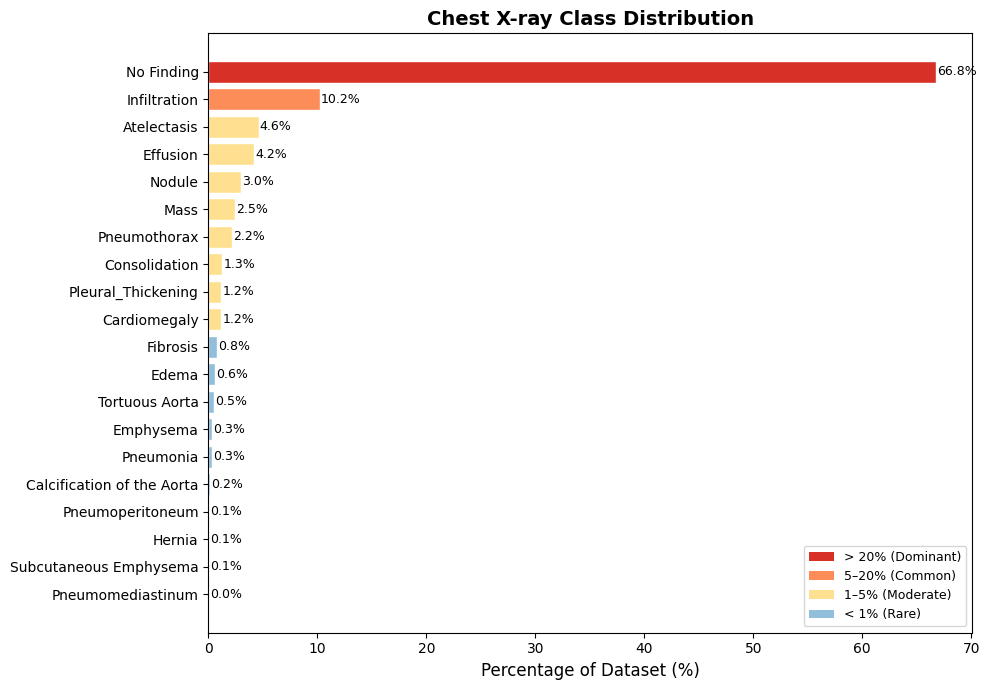

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#d73027' if p > 20 else '#fc8d59' if p > 5 else '#fee090' if p > 1
          else '#91bfdb' for p in dist_df['Percentage']]

bars = ax.barh(dist_df.index, dist_df['Percentage'], color=colors, edgecolor='white')
_ = ax.set_xlabel('Percentage of Dataset (%)', fontsize=12)
_ = ax.set_title('Chest X-ray Class Distribution', fontsize=14, fontweight='bold')
_ = ax.invert_yaxis()

for bar, pct in zip(bars, dist_df['Percentage']):
  _ = ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
              f'{pct:.1f}%', va='center', fontsize=9)

legend_elements = [
    Patch(facecolor='#d73027', label='> 20% (Dominant)'),
    Patch(facecolor='#fc8d59', label='5–20% (Common)'),
    Patch(facecolor='#fee090', label='1–5% (Moderate)'),
    Patch(facecolor='#91bfdb', label='< 1% (Rare)'),
]
_ = ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()

Display One Sample Image Per Class

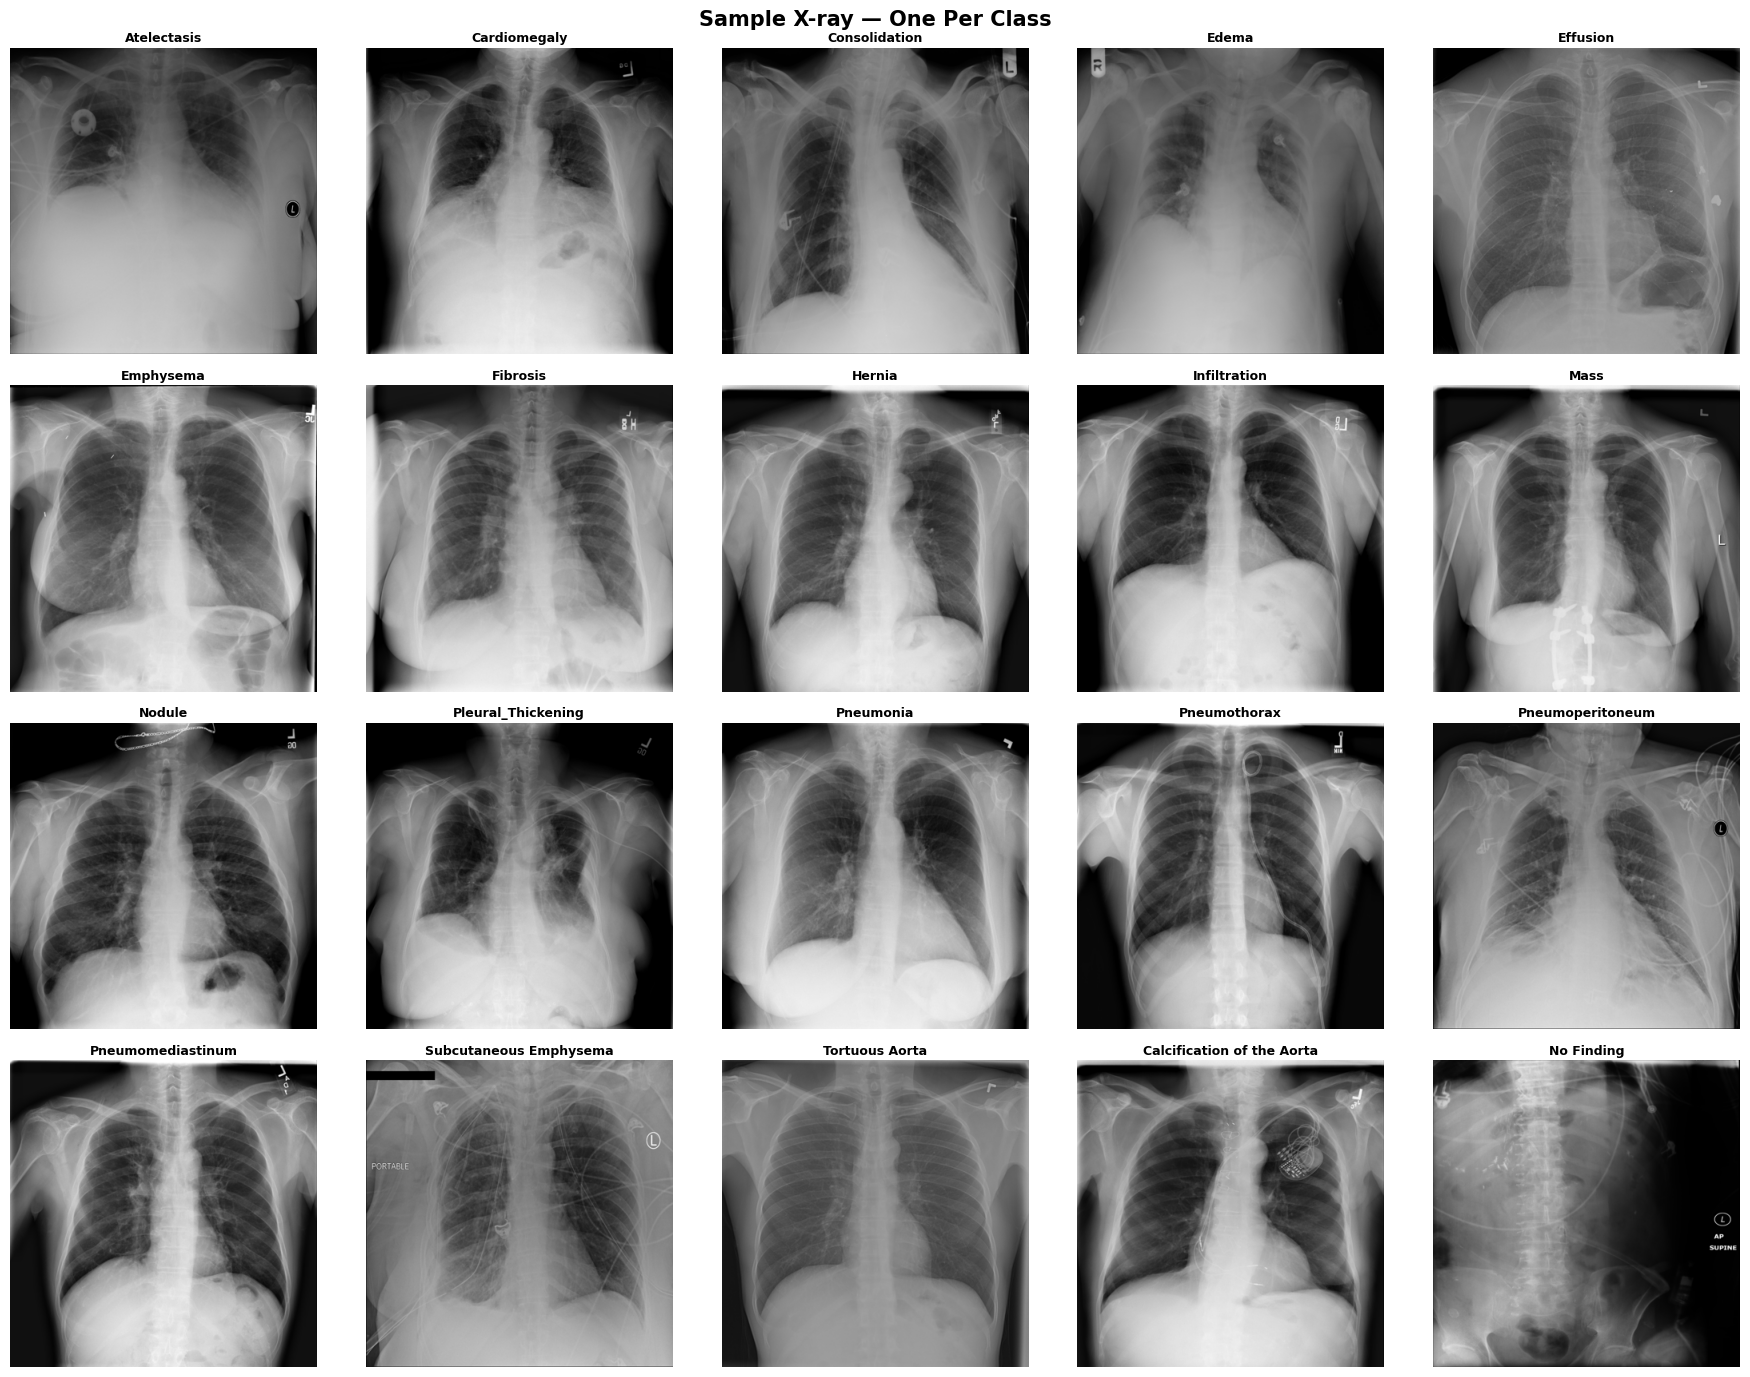

In [13]:
fig, axes = plt.subplots(4, 5, figsize=(18, 14))
axes = axes.flatten()

for idx, class_name in enumerate(class_columns):
  # Get first image of this class
  sample_id = train_df[train_df[class_name] == 1].iloc[0]['id']
  img_path = IMAGE_DIR / sample_id
  img = plt.imread(img_path)

  _ = axes[idx].imshow(img, cmap='gray')
  _ = axes[idx].set_title(class_name, fontsize=9, fontweight='bold', pad=4)
  _ = axes[idx].axis('off')

_ = plt.suptitle('Sample X-ray — One Per Class', fontsize=15, fontweight='bold')
plt.tight_layout()

Inspect a Single Image

In [14]:
# Load one image
sample_path = IMAGE_DIR / train_df.iloc[0]['id']

# --- PIL ---
img_pil = Image.open(sample_path)
print("=== PIL Info ===")
print(f"Format : {img_pil.format}")
print(f"Mode   : {img_pil.mode}")       # L = grayscale, RGB = color
print(f"Size   : {img_pil.size}")       # (Width, Height)

# --- NumPy ---
img_np = np.array(img_pil)
print("\n=== NumPy Info ===")
print(f"Shape  : {img_np.shape}")       # (H, W) or (H, W, C)
print(f"Dtype  : {img_np.dtype}")
print(f"Min    : {img_np.min()}")
print(f"Max    : {img_np.max()}")
print(f"Mean   : {img_np.mean():.2f}")

=== PIL Info ===
Format : PNG
Mode   : RGB
Size   : (384, 384)

=== NumPy Info ===
Shape  : (384, 384, 3)
Dtype  : uint8
Min    : 0
Max    : 255
Mean   : 84.09


Verify All 3 Channels Are Identical

In [15]:
img_np = np.array(Image.open(IMAGE_DIR / train_df.iloc[0]['id']))

r_channel = img_np[:, :, 0]
g_channel = img_np[:, :, 1]
b_channel = img_np[:, :, 2]

print(f"R == G : {np.array_equal(r_channel, g_channel)}")
print(f"G == B : {np.array_equal(g_channel, b_channel)}")
print(f"R == B : {np.array_equal(r_channel, b_channel)}")

R == G : True
G == B : True
R == B : True


# Preprocessing

ChestXrayDataset Class

In [16]:
class ChestXrayDataset(Dataset):
  def __init__(self, df, image_dir, transform=None):
    self.df = df.reset_index(drop=True)
    self.image_dir = Path(image_dir)
    self.transform = transform
    self.class_cols = [col for col in df.columns if col != 'id']

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    img_path = self.image_dir / row['id']
    image = Image.open(img_path).convert('RGB')
    label = int(row[self.class_cols].values.argmax())

    if self.transform:
      image = self.transform(image)

    return image, label

Train / Val Split

In [17]:
train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df[class_columns].values.argmax(axis=1)  # preserve class balance
)

print(f"Training samples:   {len(train_split_df)}")
print(f"Validation samples: {len(val_split_df)}")

Training samples:   40834
Validation samples: 10209


Transforms

In [18]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),                                   # ← ToTensor first
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.1)),      # ← then RandomErasing
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

Instantiate Datasets

In [19]:
train_dataset = ChestXrayDataset(train_split_df, IMAGE_DIR, transform=train_transform)
val_dataset = ChestXrayDataset(val_split_df,   IMAGE_DIR, transform=val_transform)

print(f"Train dataset size : {len(train_dataset)}")
print(f"Val dataset size   : {len(val_dataset)}")
print(f"Number of classes  : {len(train_dataset.class_cols)}")
print(f"Classes            : {train_dataset.class_cols}")

Train dataset size : 40834
Val dataset size   : 10209
Number of classes  : 20
Classes            : ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax', 'Pneumoperitoneum', 'Pneumomediastinum', 'Subcutaneous Emphysema', 'Tortuous Aorta', 'Calcification of the Aorta', 'No Finding']


Test With One Sample

In [20]:
image, label = train_dataset[0]

print(f"Image type    : {type(image)}")
print(f"Image shape   : {image.shape}")        # should be (3, 224, 224)
print(f"Image dtype   : {image.dtype}")
print(f"Pixel min/max : {image.min():.3f} / {image.max():.3f}")
print(f"Label index   : {label}")
print(f"Label name    : {train_dataset.class_cols[label]}")

Image type    : <class 'torch.Tensor'>
Image shape   : torch.Size([3, 224, 224])
Image dtype   : torch.float32
Pixel min/max : -1.981 / 1.908
Label index   : 19
Label name    : No Finding


Compute Class Weights

In [21]:
# Count samples per class in training split only
train_labels = train_split_df[class_columns].values.argmax(axis=1)
class_counts = torch.zeros(len(class_columns))

for label in train_labels:
  class_counts[label] += 1

total = class_counts.sum()

# 1. Inverse frequency — aggressive, rare classes get very high weights
class_weights_inv = 1.0 / class_counts
class_weights_inv = class_weights_inv / class_weights_inv.sum() * len(class_columns)

# 2. Sqrt scaling — gentle, normalized around 1.0
class_weights_sqrt = torch.sqrt(total / class_counts)
class_weights_sqrt = class_weights_sqrt / class_weights_sqrt.mean()

# 3. Log scaling — between sqrt and inv in aggressiveness
class_weights_log = torch.log(total / class_counts)
class_weights_log = class_weights_log / class_weights_log.mean()

# 4. Neg/pos ratio — adapted from BCE-style weighting
neg_counts = total - class_counts
class_weights_negpos = neg_counts / (class_counts + 1e-6)
class_weights_negpos = class_weights_negpos / class_weights_negpos.mean()

# 5. Effective Number of Samples (CVPR 2019) — beta: 0.9, 0.99, 0.999
beta = 0.999
effective_num = (1.0 - torch.pow(beta, class_counts)) / (1.0 - beta)
class_weights_ens = 1.0 / effective_num
class_weights_ens = class_weights_ens / class_weights_ens.mean()

# 6. Uniform — no reweighting, useful as a baseline
class_weights_uniform = torch.ones(len(class_columns))

In [22]:
# class_weights = class_weights_uniform   # baseline, no reweighting
# class_weights = class_weights_sqrt      # gentle, safe starting point
# class_weights = class_weights_log       # moderate
# class_weights = class_weights_negpos    # moderate-aggressive
# class_weights = class_weights_ens       # aggressive, theoretically grounded
class_weights = class_weights_inv         # most aggressive

print("Class weights:\n")
sorted_indices = class_weights.argsort()
for idx in sorted_indices:
  print(
      f"  {class_columns[idx]:<35} count: {int(class_counts[idx]):>6}   weight: {class_weights[idx]:.4f}")

print(f"\nMin weight : {class_weights.min():.4f}")
print(f"Max weight : {class_weights.max():.4f}")
print(f"Mean weight: {class_weights.mean():.4f}")

Class weights:

  No Finding                          count:  27263   weight: 0.0018
  Infiltration                        count:   4165   weight: 0.0116
  Atelectasis                         count:   1881   weight: 0.0256
  Effusion                            count:   1725   weight: 0.0279
  Nodule                              count:   1221   weight: 0.0394
  Mass                                count:    999   weight: 0.0482
  Pneumothorax                        count:    891   weight: 0.0540
  Consolidation                       count:    521   weight: 0.0924
  Pleural_Thickening                  count:    486   weight: 0.0990
  Cardiomegaly                        count:    480   weight: 0.1002
  Fibrosis                            count:    311   weight: 0.1547
  Edema                               count:    261   weight: 0.1844
  Tortuous Aorta                      count:    203   weight: 0.2370
  Emphysema                           count:    138   weight: 0.3487
  Pneumonia       

Weighted Random Sampler

In [23]:
# Assign each training sample the weight of its class
sample_weights = torch.tensor([
    class_weights[label].item() for label in train_labels
])

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print(f"Sampler created for {len(sample_weights)} training samples")

Sampler created for 40834 training samples


DataLoaders

- Run 1 — shuffle=True,   class_weights_uniform   # pure baseline
- Run 2 — shuffle=True,   class_weights_sqrt      # loss weighting only
- Run 3 — sampler=True,   class_weights_uniform   # sampler only
- Run 4 — sampler=True,   class_weights_sqrt      # both together

In [24]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    # sampler=sampler,        # replaces shuffle=True
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,          # never shuffle val
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train batches : 1277
Val batches   : 320


Verify One Batch

In [25]:
images, labels = next(iter(train_loader))

print(f"Batch image shape : {images.shape}")   # (32, 3, 224, 224)
print(f"Batch label shape : {labels.shape}")   # (32,)
print(f"Label values      : {labels.tolist()}")

# Check class distribution in this batch — should be more balanced than raw data
batch_class_counts = Counter(labels.tolist())
print("\nClass counts in this batch:")
for idx, count in sorted(batch_class_counts.items()):
  print(f"  {class_columns[idx]:<35} : {count}")

Batch image shape : torch.Size([32, 3, 224, 224])
Batch label shape : torch.Size([32])
Label values      : [19, 13, 19, 19, 19, 19, 19, 19, 0, 10, 19, 0, 19, 10, 8, 8, 4, 19, 13, 19, 19, 3, 19, 19, 19, 19, 19, 19, 19, 8, 19, 19]

Class counts in this batch:
  Atelectasis                         : 2
  Edema                               : 1
  Effusion                            : 1
  Infiltration                        : 3
  Nodule                              : 2
  Pneumothorax                        : 2
  No Finding                          : 21


Without Sampler

In [26]:
# Raw loader WITHOUT sampler — pure class distribution
raw_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
raw_images, raw_labels = next(iter(raw_loader))

raw_counts = Counter(raw_labels.tolist())
print("WITHOUT sampler — class counts in one batch:")
for idx in sorted(raw_counts.keys()):
  print(f"  {class_columns[idx]:<35} : {raw_counts[idx]}")

print(f"\n  Total classes represented: {len(raw_counts)} / 20")
print(f"\n  'No Finding' count: {raw_counts.get(class_columns.index('No Finding'), 0)}")

WITHOUT sampler — class counts in one batch:
  Atelectasis                         : 2
  Edema                               : 1
  Effusion                            : 3
  Hernia                              : 1
  Infiltration                        : 2
  Mass                                : 2
  Nodule                              : 1
  Pleural_Thickening                  : 1
  Pneumothorax                        : 1
  No Finding                          : 18

  Total classes represented: 10 / 20

  'No Finding' count: 18


# Model setup

Device Setup

In [27]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


Load Pretrained DenseNet121

In [28]:
from torchvision.models import densenet121, DenseNet121_Weights

weights = DenseNet121_Weights.DEFAULT
model = densenet121(weights=weights)

# 1. Pretraining metadata
print("=== Pretraining Meta ===")
for key, value in weights.meta.items():
  if key == 'categories':
    print(f"  {key} : {value[:10]} ... ({len(value)} total)")
  else:
    print(f"  {key} : {value}")

# 2. Recommended transforms from pretraining
print("\n=== Pretrained Transforms ===")
print(weights.transforms())

# 3. Classifier head
print("\n=== Classifier Head ===")
print(model.classifier)
print(f"Input features : {model.classifier.in_features}")

# 4. Parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n=== Parameter Count ===")
print(f"Total      : {total_params:,}")
print(f"Trainable  : {trainable_params:,}")

# 5. Feature map size at different resolutions
print("\n=== Feature Map Size Check ===")
_ = model.eval()
with torch.no_grad():
  for res in [224, 256, 320, 384]:
    dummy = torch.zeros(1, 3, res, res)
    features = model.features(dummy)
    print(f"  Input {res}x{res} → feature map {tuple(features.shape)}")

=== Pretraining Meta ===
  min_size : (29, 29)
  categories : ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich'] ... (1000 total)
  recipe : https://github.com/pytorch/vision/pull/116
  _docs : These weights are ported from LuaTorch.
  num_params : 7978856
  _metrics : {'ImageNet-1K': {'acc@1': 74.434, 'acc@5': 91.972}}
  _ops : 2.834
  _file_size : 30.845

=== Pretrained Transforms ===
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

=== Classifier Head ===
Linear(in_features=1024, out_features=1000, bias=True)
Input features : 1024

=== Parameter Count ===
Total      : 7,978,856
Trainable  : 7,978,856

=== Feature Map Size Check ===
  Input 224x224 → feature map (1, 1024, 7, 7)
  Input 256x256 → feature map (1, 1024, 8, 8)
  Input 320x320 → feature map (1, 1024, 10, 10)
  Input 384x384 → f

Replace the Classification Head

In [29]:
NUM_CLASSES = len(class_columns)  # 20

# Option A — minimal, no hidden layer
# model.classifier = nn.Linear(1024, NUM_CLASSES)

# Option B — single hidden layer, lightweight
# model.classifier = nn.Sequential(
#     nn.Linear(1024, 256),
#     nn.ReLU(),
#     nn.Dropout(p=0.3),
#     nn.Linear(256, NUM_CLASSES)
# )

# Option C — single hidden layer, standard (current)
model.classifier = nn.Sequential(
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(512, NUM_CLASSES)
)

# Option D — single hidden layer, wider
# model.classifier = nn.Sequential(
#     nn.Linear(1024, 1024),
#     nn.ReLU(),
#     nn.Dropout(p=0.3),
#     nn.Linear(1024, NUM_CLASSES)
# )

# Option E — two hidden layers, deeper
# model.classifier = nn.Sequential(
#     nn.Linear(1024, 512),
#     nn.ReLU(),
#     nn.Dropout(p=0.3),
#     nn.Linear(512, 256),
#     nn.ReLU(),
#     nn.Dropout(p=0.3),
#     nn.Linear(256, NUM_CLASSES)
# )

# Option F — two hidden layers with batch norm
# model.classifier = nn.Sequential(
#     nn.Linear(1024, 512),
#     nn.BatchNorm1d(512),
#     nn.ReLU(),
#     nn.Dropout(p=0.3),
#     nn.Linear(512, 256),
#     nn.BatchNorm1d(256),
#     nn.ReLU(),
#     nn.Dropout(p=0.3),
#     nn.Linear(256, NUM_CLASSES)
# )

print("Classifier head:")
print(model.classifier)
print(f"\nOutput classes : {NUM_CLASSES}")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")

Classifier head:
Sequential(
  (0): Linear(in_features=1024, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=512, out_features=20, bias=True)
)

Output classes : 20
Total params     : 7,488,916
Trainable params : 7,488,916


Move Model to Device

In [30]:
model = model.to(device)
print(f"Model moved to: {device}")

Model moved to: cpu


Count Trainable Parameters

In [31]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {frozen_params:,}")

Total parameters     : 7,488,916
Trainable parameters : 7,488,916
Frozen parameters    : 0


Verify Forward Pass

In [32]:
# Pass one batch through the model to confirm everything connects
_ = model.eval()
with torch.no_grad():
  sample_images, sample_labels = next(iter(train_loader))
  sample_images = sample_images.to(device)
  outputs = model(sample_images)

print(f"Input shape  : {sample_images.shape}")   # (32, 3, 224, 224)
print(f"Output shape : {outputs.shape}")          # (32, 20)
print(f"Output sample (raw logits): {outputs[0].tolist()}")

Input shape  : torch.Size([32, 3, 224, 224])
Output shape : torch.Size([32, 20])
Output sample (raw logits): [0.05077524483203888, -0.18866989016532898, 0.1303286850452423, -0.15201924741268158, 0.29859888553619385, -0.012451142072677612, 0.16423803567886353, 0.1473134607076645, -0.06160137429833412, -0.027104899287223816, 0.017345309257507324, 0.1312975436449051, 0.14209026098251343, 0.266307532787323, 0.03129804879426956, -0.0073892101645469666, 0.3269571363925934, -0.26019883155822754, -0.4265654683113098, -0.25010278820991516]


Peek at Untrained Predictions

In [33]:
# Get predicted class index (highest logit) for each image in batch
predicted_indices = outputs.argmax(dim=1)

print(f"{'True Label':<35} {'Predicted Label':<35} {'Correct?'}")
print("-" * 80)
for true_idx, pred_idx in zip(sample_labels, predicted_indices):
  true_name = class_columns[true_idx.item()]
  pred_name = class_columns[pred_idx.item()]
  correct = "✅" if true_idx == pred_idx else "❌"
  print(f"{true_name:<35} {pred_name:<35} {correct}")

True Label                          Predicted Label                     Correct?
--------------------------------------------------------------------------------
No Finding                          Subcutaneous Emphysema              ❌
No Finding                          Effusion                            ❌
Cardiomegaly                        Pneumothorax                        ❌
No Finding                          Fibrosis                            ❌
Infiltration                        Subcutaneous Emphysema              ❌
No Finding                          Effusion                            ❌
Effusion                            Effusion                            ✅
No Finding                          Effusion                            ❌
No Finding                          Hernia                              ❌
No Finding                          Effusion                            ❌
No Finding                          Effusion                            ❌
Infiltration            

Focal Loss Definition

In [34]:
class FocalLoss(nn.Module):
  def __init__(self, gamma=2, weight=None):
    super().__init__()
    self.gamma = gamma
    self.weight = weight

  def forward(self, outputs, labels):
    ce_loss = F.cross_entropy(outputs, labels,
                              weight=self.weight, reduction='none')
    pt = torch.exp(-ce_loss)
    focal_loss = ((1 - pt) ** self.gamma) * ce_loss
    return focal_loss.mean()

Loss functions

In [35]:
# Option A — Cross Entropy
# criterion = nn.CrossEntropyLoss(
#     weight=class_weights.to(device)
# )

# Option B — Cross Entropy with label smoothing
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
    label_smoothing=0.1
)

# Option C — Focal Loss, moderate (good starting point)
# criterion = FocalLoss(
#     gamma=2,
#     weight=class_weights.to(device)
# )

# Option D — Focal Loss, aggressive (heavy focus on hard samples)
# criterion = FocalLoss(
#     gamma=5,
#     weight=class_weights.to(device)
# )

# Option E — Cross Entropy, no class weights (pure baseline)
# criterion = nn.CrossEntropyLoss()

Optimizers

In [36]:
# Option A — Adam, standard
# optimizer = torch.optim.Adam(
#     model.parameters(),
#     lr=1e-4
# )

# Option B — AdamW, standard
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# Option C — AdamW, stronger regularization
# optimizer = torch.optim.AdamW(
#     model.parameters(),
#     lr=1e-4,
#     weight_decay=1e-2
# )

# Option D — AdamW, differential learning rates
#            lower lr for pretrained backbone, higher for new classifier head
# optimizer = torch.optim.AdamW([
#     {'params': model.features.parameters(),    'lr': 1e-5},
#     {'params': model.classifier.parameters(),  'lr': 1e-3}
# ], weight_decay=1e-4)

# Option E — SGD with momentum
# optimizer = torch.optim.SGD(
#     model.parameters(),
#     lr=1e-3,
#     momentum=0.9,
#     weight_decay=1e-4
# )

Schedulers

In [37]:
# Option A — Cosine annealing
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

# Option B — Step decay, halve lr every 5 epochs
# scheduler = torch.optim.lr_scheduler.StepLR(
#     optimizer,
#     step_size=5,
#     gamma=0.5
# )

# Option C — Reduce on plateau, patience based
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode='min',
#     factor=0.5,
#     patience=3,
#     min_lr=1e-6
# )

# Option D — Warmup + cosine decay
#            linear warmup for 1 epoch then cosine decay
# def lr_lambda(epoch):
#     if epoch < 1:
#         return epoch + 1
#     return 0.5 * (1 + torch.cos(torch.tensor((epoch - 1) / (NUM_EPOCHS - 1) * 3.14159)))
# scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Option E — No scheduling, constant lr
# scheduler = torch.optim.lr_scheduler.ConstantLR(optimizer, factor=1.0)

Overview: Training Configuration

In [38]:
print("=== Training Configuration ===\n")
print(f"  Loss      : {criterion.__class__.__name__}", end="")
if hasattr(criterion, 'label_smoothing') and criterion.label_smoothing > 0:
  print(f" (label_smoothing={criterion.label_smoothing})", end="")
if hasattr(criterion, 'gamma'):
  print(f" (gamma={criterion.gamma})", end="")
if hasattr(criterion, 'weight') and criterion.weight is not None:
  print(f" (class_weights=True)", end="")
print()

print(f"  Optimizer : {optimizer.__class__.__name__}", end="")
param_groups = optimizer.param_groups
if len(param_groups) == 1:
  print(f" (lr={param_groups[0]['lr']}, weight_decay={param_groups[0]['weight_decay']})", end="")
else:
  print(f" (differential lr — {len(param_groups)} param groups)", end="")
print()

print(f"  Scheduler : {scheduler.__class__.__name__}")
print(f"\n  Epochs    : {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Patience  : {PATIENCE}")
print(f"  Device    : {device}")

=== Training Configuration ===

  Loss      : CrossEntropyLoss (label_smoothing=0.1) (class_weights=True)
  Optimizer : AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler : CosineAnnealingLR

  Epochs    : 2
  Batch size: 32
  Patience  : 5
  Device    : cpu


Verify Loss on One Batch

In [39]:
_ = model.train()
sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

outputs = model(sample_images)
loss = criterion(outputs, sample_labels)

print(f"Output shape : {outputs.shape}")
print(f"Loss value   : {loss.item():.4f}")

Output shape : torch.Size([32, 20])
Loss value   : 23.7559


Train One Epoch Function

In [40]:
def train_one_epoch(model, loader, criterion, optimizer, device):
  model.train()
  total_loss = 0
  correct = 0
  total = 0

  log_interval = 1 if DEBUG else 50

  for batch_idx, (images, labels) in enumerate(loader):
    if DEBUG and batch_idx >= DEBUG_BATCHES:
      break

    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    predicted = outputs.argmax(dim=1)
    correct += (predicted == labels).sum().item()
    total += labels.size(0)

    if (batch_idx + 1) % log_interval == 0:
      print(f"  Batch {batch_idx+1}/{len(loader)} "
            f"| Loss: {loss.item():.4f}")

  return total_loss / (DEBUG_BATCHES if DEBUG else len(loader)), correct / total * 100

Validate One Epoch Function

In [41]:
def validate(model, loader, criterion, device):
  model.eval()
  total_loss = 0
  correct = 0
  total = 0

  with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(loader):
      if DEBUG and batch_idx >= DEBUG_BATCHES:
        break

      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels)

      total_loss += loss.item()
      predicted = outputs.argmax(dim=1)
      correct += (predicted == labels).sum().item()
      total += labels.size(0)

      if DEBUG:
        print(f"  Val Batch {batch_idx+1}/{DEBUG_BATCHES} "
              f"| Loss: {loss.item():.4f}")

  num_batches = DEBUG_BATCHES if DEBUG else len(loader)
  return total_loss / num_batches, correct / total * 100

Training Function

In [42]:
CHECKPOINT_DIR = Path("models")
CHECKPOINT_PATH = CHECKPOINT_DIR / "best_model.pth"

In [43]:
def save_checkpoint(model, optimizer, scheduler,
                    epoch, best_val_loss, no_improve_count, history):
  CHECKPOINT_DIR.mkdir(exist_ok=True)
  torch.save({
      'epoch': epoch,
      'model_state': model.state_dict(),
      'optimizer_state': optimizer.state_dict(),
      'scheduler_state': scheduler.state_dict(),
      'best_val_loss': best_val_loss,
      'no_improve_count': no_improve_count,
      'history': history,
  }, CHECKPOINT_PATH)


def load_checkpoint(model, optimizer, scheduler, device):
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
  model.load_state_dict(checkpoint['model_state'])
  optimizer.load_state_dict(checkpoint['optimizer_state'])
  scheduler.load_state_dict(checkpoint['scheduler_state'])
  return (
      checkpoint['epoch'],
      checkpoint['best_val_loss'],
      checkpoint['no_improve_count'],
      checkpoint['history']
  )

In [44]:
def run_training(model, train_loader, val_loader,
                 criterion, optimizer, scheduler, device):

  # --- Resume or fresh start ---
  if CHECKPOINT_PATH.exists():
    start_epoch, best_val_loss, no_improve_count, history = \
        load_checkpoint(model, optimizer, scheduler, device)
    start_epoch += 1   # resume from next epoch
    print(f"🔄 Resuming from checkpoint — epoch {start_epoch + 1}, "
          f"best val loss: {best_val_loss:.4f}")
  else:
    start_epoch = 0
    best_val_loss = float('inf')
    no_improve_count = 0
    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}
    print("🚀 Starting training from scratch")

  print(f"Epochs: {NUM_EPOCHS} | Batch size: {BATCH_SIZE} | Patience: {PATIENCE}")
  print(f"Debug mode: {DEBUG}" +
        (f" | Batches/epoch: {DEBUG_BATCHES} | Epochs: {DEBUG_EPOCHS}" if DEBUG else ""))
  print("=" * 70)

  for epoch in range(start_epoch, NUM_EPOCHS):
    start_time = time.time()

    # --- Train ---
    print(f"\nEpoch {epoch+1:02d}/{NUM_EPOCHS} — Training started...")
    train_loss, train_acc = train_one_epoch(model, train_loader,
                                            criterion, optimizer, device)
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} — Training complete. "
          f"Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%")

    # --- Validate ---
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} — Validation started...")
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} — Validation complete. "
          f"Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%")

    scheduler.step()

    elapsed = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']

    # --- Epoch summary ---
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"\n── Epoch {epoch+1:02d} Summary ──────────────────────────────────────")
    print(f"  Time : {elapsed:.0f}s | LR: {current_lr:.6f}")
    print(f"  Train → Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%")
    print(f"  Val   → Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%")

    # --- Checkpoint ---
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      no_improve_count = 0
      save_checkpoint(model, optimizer, scheduler,
                      epoch, best_val_loss, no_improve_count, history)
      print(f"  ✅ Best model saved! (val_loss: {best_val_loss:.4f})")
    else:
      no_improve_count += 1
      print(f"  ⚠️  No improvement ({no_improve_count}/{PATIENCE})")

    # --- Early stopping ---
    if no_improve_count >= PATIENCE:
      print("\n🛑 Early stopping triggered.")
      break

  print("\n✅ Training complete!")
  print(f"Best validation loss: {best_val_loss:.4f}")
  return history

Run Training

In [45]:
history = run_training(model, train_loader, val_loader,
                       criterion, optimizer, scheduler, device)

🚀 Starting training from scratch
Epochs: 2 | Batch size: 32 | Patience: 5
Debug mode: True | Batches/epoch: 5 | Epochs: 2

Epoch 01/2 — Training started...
  Batch 1/1277 | Loss: 25.8740
  Batch 2/1277 | Loss: 33.4238
  Batch 3/1277 | Loss: 11.6412
  Batch 4/1277 | Loss: 9.3066
  Batch 5/1277 | Loss: 24.1869
Epoch 01/2 — Training complete. Loss: 20.8865  Acc: 0.62%
Epoch 01/2 — Validation started...
  Val Batch 1/5 | Loss: 16.3751
  Val Batch 2/5 | Loss: 15.4073
  Val Batch 3/5 | Loss: 16.7521
  Val Batch 4/5 | Loss: 21.2980
  Val Batch 5/5 | Loss: 23.5438
Epoch 01/2 — Validation complete. Loss: 18.6753  Acc: 0.00%

── Epoch 01 Summary ──────────────────────────────────────
  Time : 33s | LR: 0.000051
  Train → Loss: 20.8865  Acc: 0.62%
  Val   → Loss: 18.6753  Acc: 0.00%
  ✅ Best model saved! (val_loss: 18.6753)

Epoch 02/2 — Training started...
  Batch 1/1277 | Loss: 12.9292
  Batch 2/1277 | Loss: 11.5021
  Batch 3/1277 | Loss: 20.1034
  Batch 4/1277 | Loss: 16.8984
  Batch 5/1277 | 

Plot Training History

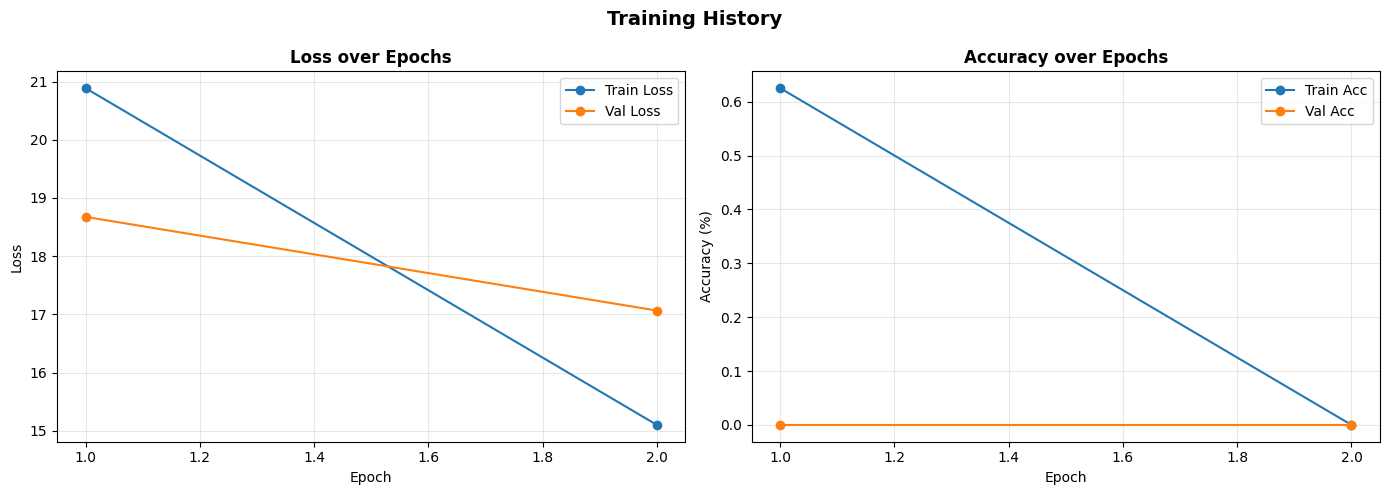

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history['train_loss']) + 1)

# Loss plot
_ = axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss', marker='o')
_ = axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss',   marker='o')
_ = axes[0].set_title('Loss over Epochs', fontweight='bold')
_ = axes[0].set_xlabel('Epoch')
_ = axes[0].set_ylabel('Loss')
_ = axes[0].legend()
_ = axes[0].grid(True, alpha=0.3)

# Accuracy plot
_ = axes[1].plot(epochs_ran, history['train_acc'], label='Train Acc', marker='o')
_ = axes[1].plot(epochs_ran, history['val_acc'],   label='Val Acc',   marker='o')
_ = axes[1].set_title('Accuracy over Epochs', fontweight='bold')
_ = axes[1].set_xlabel('Epoch')
_ = axes[1].set_ylabel('Accuracy (%)')
_ = axes[1].legend()
_ = axes[1].grid(True, alpha=0.3)

_ = plt.suptitle('Training History', fontsize=14, fontweight='bold')
_ = plt.tight_layout()

Test Dataset Class

In [47]:
class TestDataset(Dataset):
  def __init__(self, test_csv, image_dir, transform=None):
    self.df = pd.read_csv(test_csv)
    self.image_dir = Path(image_dir)
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    img_id = self.df.iloc[idx]['id']
    img_path = self.image_dir / img_id
    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image)

    return image, img_id


test_dataset = TestDataset(TEST_CSV, IMAGE_DIR, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=32,
                         shuffle=False, num_workers=2, pin_memory=True)

print(f"Test samples : {len(test_dataset)}")
print(f"Test batches : {len(test_loader)}")

Test samples : 17015
Test batches : 532


In [48]:
SUBMISSION_DIR = Path("submissions")


def generate_submission(model, test_loader, class_columns, device):
  model.eval()
  all_ids = []
  all_preds = []

  total_batches = len(test_loader)
  print(f"Generating predictions over {total_batches} batches...\n")

  with torch.no_grad():
    for batch_idx, (images, img_ids) in enumerate(test_loader):
      images = images.to(device)
      outputs = model(images)
      preds = outputs.argmax(dim=1).cpu().numpy()

      all_ids.extend(img_ids)
      all_preds.extend(preds)

      if (batch_idx + 1) % 50 == 0 or (batch_idx + 1) == total_batches:
        print(f"  Batch {batch_idx + 1:>4}/{total_batches} "
              f"({(batch_idx + 1) / total_batches * 100:.1f}%) complete")

  # Build one-hot encoded dataframe
  submission = pd.DataFrame(0,
                            index=range(len(all_ids)),
                            columns=['id'] + class_columns)
  submission['id'] = all_ids

  for i, pred_idx in enumerate(all_preds):
    submission.iloc[i, pred_idx + 1] = 1

  # Verify format — each row must have exactly one 1
  row_sums = submission[class_columns].sum(axis=1)
  assert (row_sums == 1).all(), "❌ Some rows don't have exactly one 1!"

  SUBMISSION_DIR.mkdir(exist_ok=True)
  submission_path = SUBMISSION_DIR / "submission.csv"
  submission.to_csv(submission_path, index=False)

  print(f"\n✅ Submission saved to {submission_path}")
  print(f"   Rows    : {len(submission)}")
  print(f"   Columns : {len(submission.columns)}")
  print(f"\nPrediction distribution:")
  pred_counts = submission[class_columns].sum().sort_values(ascending=False)
  for cls, count in pred_counts[pred_counts > 0].items():
    pct = count / len(submission) * 100
    print(f"  {cls:<35}: {count:>5}  ({pct:.1f}%)")

  return submission

In [ ]:
LOAD_BEST_MODEL = False

if LOAD_BEST_MODEL:
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
  model.load_state_dict(checkpoint['model_state'])
  print(f"✅ Best model loaded from {CHECKPOINT_PATH} "
        f"(val_loss: {checkpoint['best_val_loss']:.4f}, "
        f"epoch: {checkpoint['epoch'] + 1})")
else:
  print("⚠️  Using current in-scope model (no checkpoint loaded)")

# Generate submission
submission = generate_submission(model, test_loader, class_columns, device)
print("\nFirst 5 rows:")
print(submission.head())

⚠️  Using current in-scope model (no checkpoint loaded)
Generating predictions over 532 batches...

